# Topic 4. Curry-Howard correspondence

![haskell](../../images/haskellcurry.jpeg) Haskell Brooks Curry

![howard](../../images/howard-resize.jpg)Willian Howard

Nobody designed this correspondence: it was _noticed_, twice, thirty-five years apart, and both times by someone who had two unrelated things in front of him and realised they were the same thing.

__What Curry saw, in 1934.__ On one side, a Hilbert-style proof system for implication, whose axiom schemes are:

$$
\begin{array}{ll}
\mathrm{K} & p \rightarrow (q \rightarrow p) \\
\mathrm{S} & (p \rightarrow (q \rightarrow r)) \rightarrow ((p \rightarrow q) \rightarrow (p \rightarrow r))
\end{array}
$$

On the other side, with no relation to logic whatsoever, Schönfinkel's combinators `K` and `S`, whose types are:

`K: P => Q => P` and `S: (P => Q => R) => (P => Q) => P => R`

The very same two formulas. And so a derivation of $p \rightarrow r$ out of $p \rightarrow q$ and $q \rightarrow r$ turns out to be a program — the composition of two functions:

```
 1  q → r              g          prem
 2  p → (q → r)        K g        K 1
 3  (p → q) → (p → r)  S (K g)    S 2
 4  p → q              f          prem
 5  p → r              S (K g) f  MP 3, 4
```

The third column is the whole point: before Curry, the left-hand side lived in papers about logic and the right-hand side in papers about combinators, and nothing paired them.

__What Howard saw, in 1969.__ Curry's observation covered implication only. Howard extended it to the whole of Gentzen's natural deduction — conjunction, disjunction and the rest — with Church's lambda calculus on the computational side. His example was $a \wedge b \rightarrow b \wedge a$, proved like this:

```
 1  │ a ∧ b        hyp¹
 2  │ b            ∧E₂ 1
 3  │ a            ∧E₁ 1
 4  │ b ∧ a        ∧I 2, 3
 5  a ∧ b → b ∧ a  →I¹ 1–4
```

and inhabited by this program:

`(x: (A, B)) => (x._2, x._1)`

If the proof notation is still opaque, don't worry: it is the lines view, and we introduce it properly a few cells below. The rest of this notebook is Howard's observation, written in Scala.

Both observations are the same observation, and it can be stated in one line: __logic and programming are not two subjects that resemble each other, they are one subject__. Curry found it in the axioms of implication, Howard in the whole of natural deduction, and what survives from them are two slogans:

$$
\begin{array}{cc}
\mathrm{\bf Computation} & \mathrm{\bf Logic} \\
\hline
\mathrm{Types} & \mathrm{Propositions} \\
\mathrm{Programs} & \mathrm{Proofs}
\end{array}
$$

__Propositions as types__: a type _is_ a proposition, so when we write a type signature we are stating something that has to be proved. __Proofs as programs__: implementing that signature _is_ proving it — the program does not describe the proof, it is the proof.

This is the second of these correspondences we meet, and the two fit together. In the previous topic, algebraic data types gave us a correspondence with _arithmetic_: `Either` was a sum, a tuple a product, a function an exponential, `Unit` the one and `Nothing` the zero — and counting the values of a type turned out to be evaluating an arithmetic expression. Now the very same types get read a second time, in a second language:

| Type | ... as arithmetic | ... as logic |
|---|---|---|
| `(A, B)` | $a \times b$ | $a \wedge b$ |
| `Either[A, B]` | $a + b$ | $a \vee b$ |
| `A => B` | $b^{a}$ | $a \rightarrow b$ |
| `Unit` | $1$ | $true$ |
| `Nothing` | $0$ | $false$ |

But "the program _is_ the proof" is a strong claim, and so far it is only a slogan. So here is the question this notebook has to answer, and it is worth holding on to while you read:

> __In what sense are they _exactly_ the same thing — not two objects that happen to correspond, but one object seen from two sides?__

<img src="../../images/icon-lambda-to-turnstile.gif" width="132" alt="lambda turning into turnstile"/> <img src="../../images/icon-turnstile-to-lambda.gif" width="132" alt="turnstile turning into lambda"/>

One coin, turning: which face you see depends on where you are standing, not on which of them is the real one. The answer comes in three steps — how proofs are built, how programs are built, and then the two tables of rules laid over each other.

### References

[__The Curry-Howard correspondence__](https://en.wikipedia.org/wiki/Curry%E2%80%93Howard_correspondence) Wikpedia. 

[__Propositions as types__](https://homepages.inf.ed.ac.uk/wadler/papers/propositions-as-types/propositions-as-types.pdf). Philip Wadler. 

[__Intuitionistic logic__](https://en.wikipedia.org/wiki/Intuitionistic_logic). Wikipedia.

# You can play it!

Before any theory at all, here is the shortest route into that question: play it. The [__Curry-Howard game__](https://jserranohidalgo.github.io/curry-howard-game/) ([sources](https://github.com/jserranohidalgo/curry-howard-game)) hands you a proposition and an empty program, and asks you to finish it. You pick a hole, the game offers you the rules that apply to that goal, and every move you make writes __both__ a line of a proof and a piece of a program — the coin, turning, at every move. It runs in the browser, with no account and nothing to install.

Three goals to try, in this order:

* $a \wedge b \rightarrow b \wedge a$ — Howard's own example, the one above. Two moves and it is done.
* $p \wedge (q \vee r) \rightarrow (p \wedge q) \vee (p \wedge r)$ — the example this notebook builds by hand later on. Play it now, and when we grow it step by step below, check whether the game forced the same choices you made.
* $p \vee \neg p$ — you will not win this one, no matter how well you play. Finding out _why_ you cannot is the subject of the last two sections.

Play a few moves before reading on: the sections that follow are, in essence, an explanation of what your moves were doing. The application also carries two talks — one on what the correspondence is, Curry's and Howard's observations again, and one on how the game is played.

# How proofs are made

Before we can compare a proof with a program we have to say what a proof _is_, and that means fixing a formal system. Ours is Gentzen's natural deduction, the one you already met in your logic course, and its entire content is a table of rules: for every connective, an __introduction__ rule (how to conclude a formula whose main operator is that connective) and an __elimination__ rule (what a formula with that connective entitles you to conclude). Nothing else is allowed.

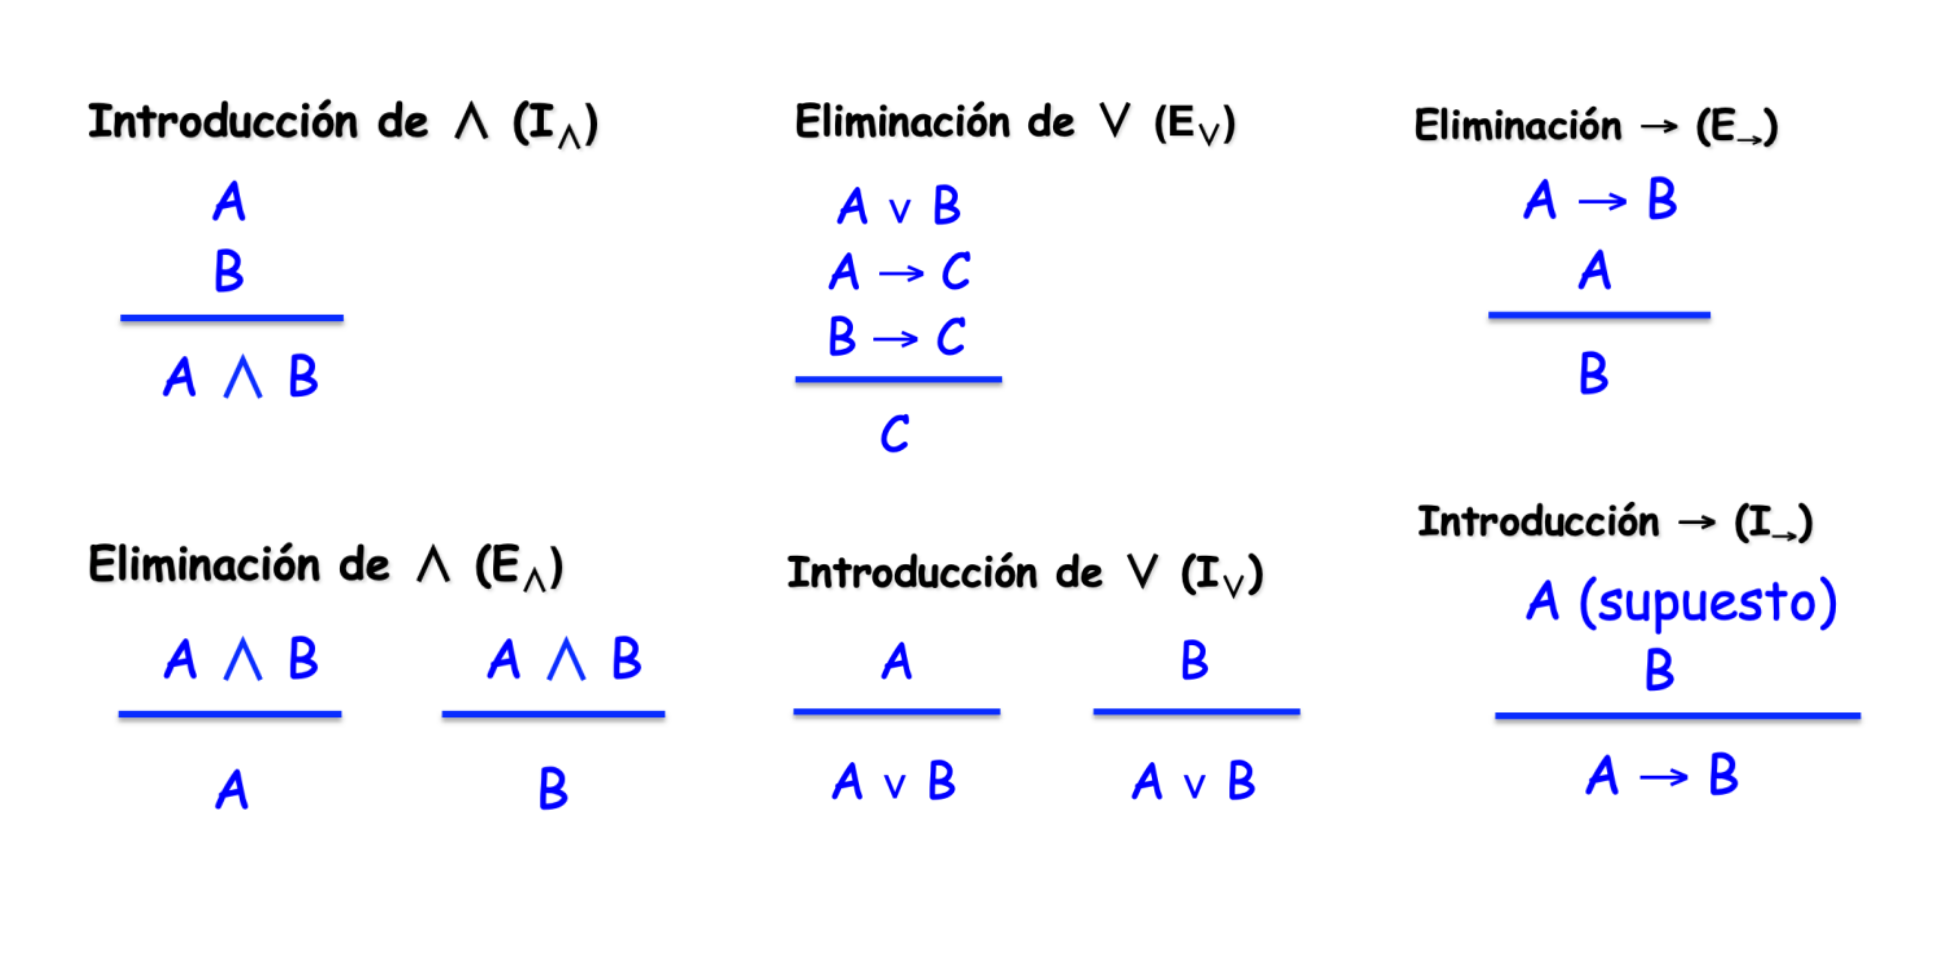

Note that we only have two rules more: the axiom (`Ax`) and elimination rule for `false` ($ \bot E$). 

And that is all natural deduction is. Let's fix the example we will carry through the whole notebook,

$$\vdash p \wedge (q \vee r) \rightarrow (p \wedge q) \vee (p \wedge r)$$

and prove it. The proof below is written in the __lines view__ — the rendering the game uses, and the notation a good many logic courses teach in. One line per step, numbered from the top; the vertical bars are __subproofs__, each opened by an assumption (`hyp¹`) and closed by the rule that discharges it, which cites the whole span (`1–11`); and the right-hand column names, for every single line, __the rule that justifies it and the lines it uses__. No line may be there for any other reason, so that column _is_ the structure of the proof.

```
 1  │ p ∧ (q ∨ r)                hyp¹
 2  │ q ∨ r                      ∧E₂ 1
 3  │ │ q                        hyp²
 4  │ │ p                        ∧E₁ 1
 5  │ │ p ∧ q                    ∧I 4, 3
 6  │ │ p ∧ q ∨ p ∧ r            ∨I₁ 5
 7  │ │ r                        hyp³
 8  │ │ p                        ∧E₁ 1
 9  │ │ p ∧ r                    ∧I 8, 7
10  │ │ p ∧ q ∨ p ∧ r            ∨I₂ 9
11  │ p ∧ q ∨ p ∧ r              ∨E²³ 2, 3–6, 7–10
12  p ∧ (q ∨ r) → p ∧ q ∨ p ∧ r  →I¹ 1–11
```

Read it as a story: assume the antecedent (1), take it apart (2), and then — because line 2 is a disjunction and there is no way to know which side we are on — argue twice, once under `q` (3–6) and once under `r` (7–10), reaching the same conclusion both times. Line 11 is what that entitles us to, and line 12 discharges the assumption. The game can also draw this same proof as a Gentzen tree; it is the same proof in another shape.

# How programs are made

Now the other side — and this too is a summary of something you already know. The algebraic data types of the previous topic come with exactly the same kind of table, the one we used there for _type-driven development_: for every type former, the __constructors__ that build a value of it, and the __destructors__ that take one apart.

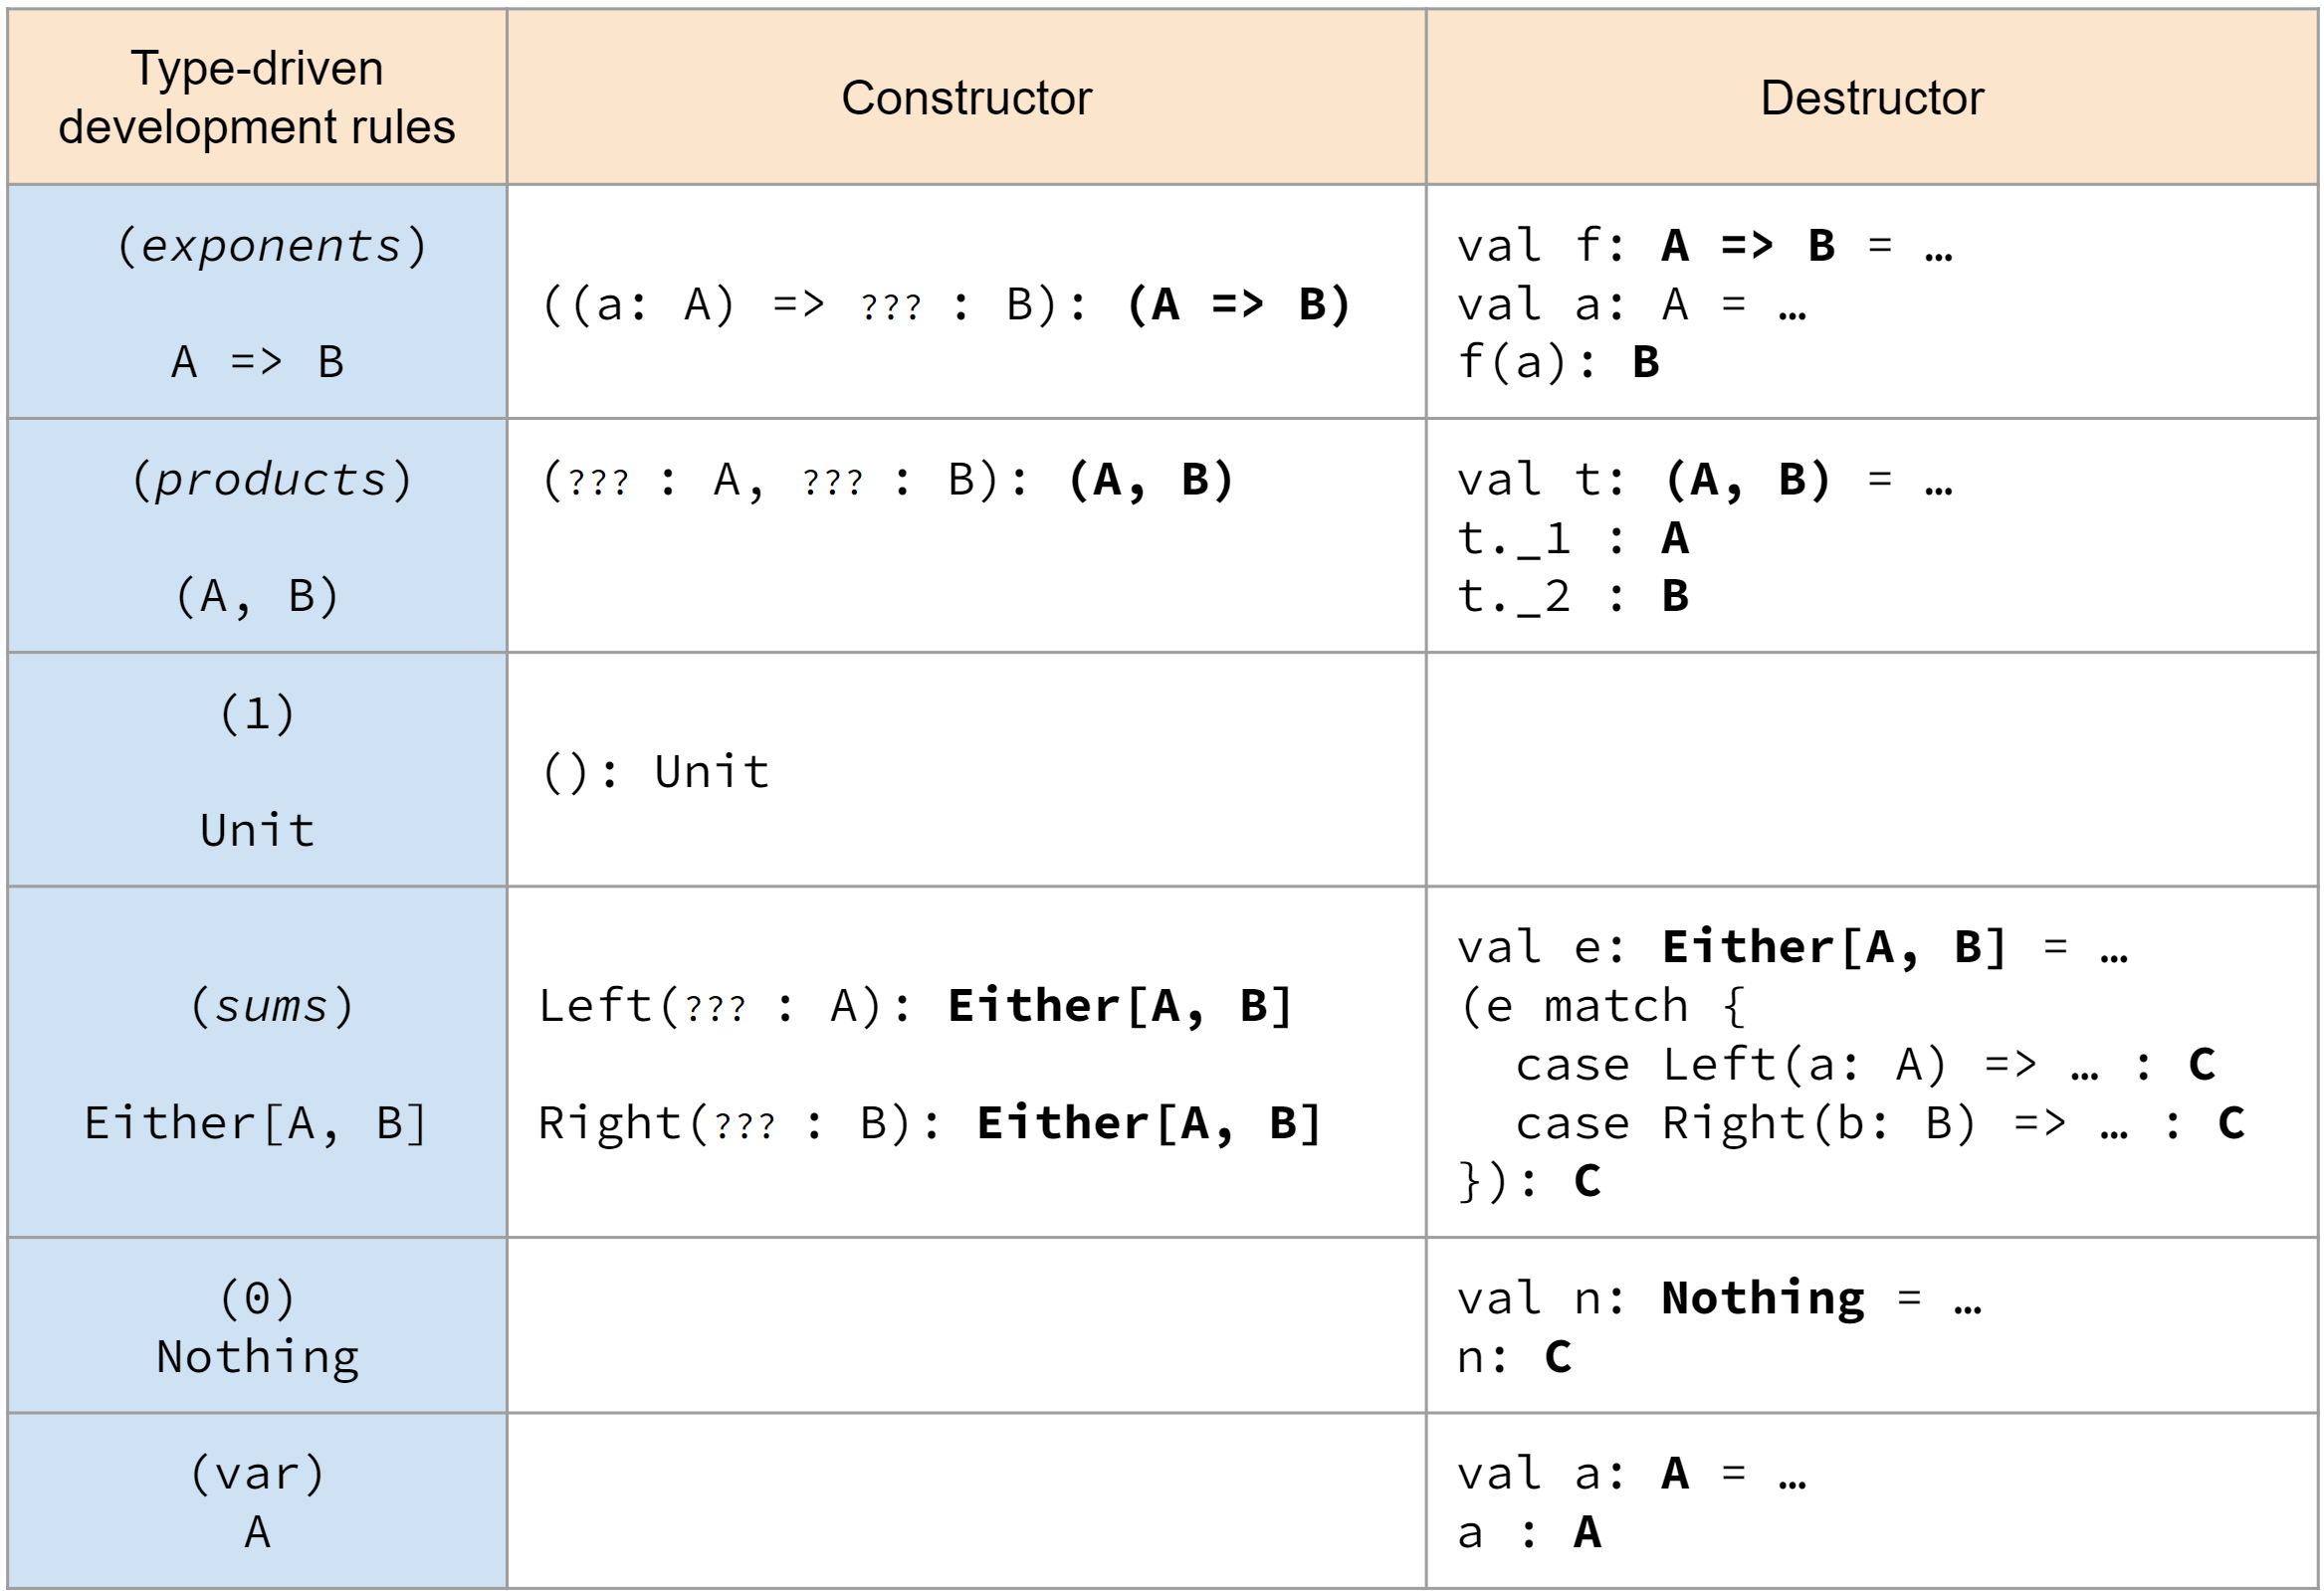

These constructors and destructors say how values of each algebraic data type can be created, and which information can be extracted from them. Note the last row, `var`, which was added to the table for the same reason it appears here: if a value of type `A` is already in scope, we may simply observe it.

Keep this table beside the previous one. Building and taking apart on this side; introducing and eliminating on the other.

Now, the example again — but on this side. The proposition above will turn out to correspond to the type `((P, Either[Q, R])) => Either[(P, Q), (P, R)]`, so let's implement it, in the most ordinary Scala we can write:

In [5]:
def program[P, Q, R]: ((P, Either[Q, R])) => Either[(P, Q), (P, R)] = 
    case (p, Left(q)) => Left((p, q))
    case (p, Right(r)) => Right((p, r))

defined function program

And here is _its_ structure, in terms of the table above — the column that plays the role that the rule names played in the proof:

| In the program | Operation | Row of the table |
|---|---|---|
| the function itself, `... => ...` | lambda | `(exponents)`, constructor |
| `case (p, ...)` | taking a pair apart (by pattern, rather than `._1`/`._2`) | `(products)`, destructor |
| `case Left(q)` / `case Right(r)` | `match` on an `Either` | `(sums)`, destructor |
| `p`, `q`, `r` | a value already in scope | `(var)`, destructor |
| `(p, q)` | building a pair | `(products)`, constructor |
| `Left(...)` / `Right(...)` | building an `Either` | `(sums)`, constructor |

Six operations, and every one of them was forced by a type.

# Propositions as types

So: we have a proof, built out of introduction and elimination rules, and we have a program, built out of constructors and destructors. Two artifacts, from two courses, written in two notations.

__In what sense are they the same?__

The answer begins with a dictionary. Read the proposition as a type:

We put forward now the following correspondence: 

$$ 
\begin{array}{cc}
\mathrm{\bf Scala\ ADTs} & \mathrm{\bf Logic} \\
\hline
\mathtt{Unit} & \top \\
\mathtt{Nothing} & \bot \\
\mathtt{Either[P, Q]} & p \vee q \\
\mathtt{(P, Q)} & p \wedge q \\
\mathtt{P => Q} & p \rightarrow q 
\end{array}
$$


so that, for instance, the following type:

```scala
((P => Q, P)) => Q
```

corresponds to the following formula of propositional logic: 

$\hspace{0.8cm}(p \rightarrow q) \wedge p \rightarrow q$

Let's get used to read Scala types as propositional formulas with these examples: 

$$
\begin{array}{cc}
\mathrm{\bf Scala\ types} & \mathrm{\bf Propositions} \\
\hline
\mathtt{(P, Either[Q, R])} & p \wedge (q\vee r) \\ 
\mathtt{P => Q => (Q, R)} & p \rightarrow q \rightarrow q \wedge r \\
\mathtt{(P => Nothing) => Nothing} & (p \rightarrow \bot) \rightarrow \bot \\ 
\end{array}
$$

What about logical negation and equivalence? They are commonly regarded as abbreviations: 

* $\neg p$ abbreviates $p \rightarrow \bot$ (i.e. if we assume $p$, we reach a contradiction)
* $p \leftrightarrow q$ abbreviates $p \rightarrow q \wedge q \rightarrow p$ 

so, they will be represented in Scala through the following type aliases: 

In [2]:
type Not[P] = P => Nothing
type <=>[P, Q] = (P => Q, Q => P)

defined type Not
defined type <=>

Let's translate the following propositional formulas to Scala types: 


$$ 
\begin{array}{cc}
\mathrm{\bf Logic} & \mathrm{\bf Scala\ ADTs} \\
\hline
(p \wedge q \rightarrow r) \leftrightarrow (p \rightarrow q \rightarrow r) & \mathtt{(((P,Q)) => R) <=> (P => Q => R)} \\
\neg (p \wedge q) \rightarrow \neg p \vee \neg q & \mathtt{Not[(P, Q)] => Either[Not[P], Not[Q]]}\\
\neg\neg(p \vee \neg p) & \mathtt{Not[Not[Either[P, Not[P]]]]}\\
p \vee (q \wedge r) \leftrightarrow (p \vee q) \wedge (p \vee r) & 
\mathtt{Either[P, (Q, R)] <=> (Either[P, Q], Either[P, R])}
\end{array}
$$


Note that $p \wedge q \rightarrow r$ translates to `((P,Q)) => R`, and not to `(P, Q) => R`. The former is a `Function1` which receives a single argument of tuple type `(P, Q)`; the latter is a `Function2` which receives two arguments of types `P` and `Q`. 

In sum, the rules for introducing and elliminating the logical operators of natural deduction are in __one-to-one__ correspondence with the constructors and destructors of algebraic data types. Put the two tables of the previous sections side by side and read them row by row: `∧I` is the pair constructor and `∧E₁`/`∧E₂` are its two projections; `∨I₁`/`∨I₂` are `Left` and `Right`, and `∨E` is the `match`; `→I` is the lambda and `→E` is application; `⊥E` is the value of type `Nothing`, which fits any goal at all; and the axiom is the `var` row. There is no row on either side without its counterpart on the other.

> __▸ The same thing, read twice.__ That is the answer to the question we opened with, in its most compact form: there is not a table of logical rules and, beside it, a table of type operations. There is __one__ table, written down twice. Turn the coin one way and a row is an introduction or an elimination rule of natural deduction; turn it the other way and the very same row is a constructor or a destructor of an algebraic data type. Every example from here on comes in both readings, so it pays to make a ritual of it: when you are given one side, try to write the other before reading on.

# Proofs as programs, step by step

This is where the correspondence stops being an observation and starts being a __method__. If proofs are programs, then when you are asked to prove a tautology you do not have to reason inside the proof system at all. You can cross over, work on the side where you have a compiler, and cross back:

$$
\begin{array}{ccc}
\mathrm{proposition} & \longleftrightarrow & \mathrm{type} \\
\big\downarrow & & \big\downarrow \\
\mathrm{proof} & \longleftrightarrow & \mathrm{program}
\end{array}
$$

Go right along the top row (translate the proposition into a type, with the dictionary), then down the right-hand column (develop a program of that type, by type-driven development — the method of the previous topic, with holes and the table of constructors and destructors), and then left along the bottom row (read the finished program back as a proof, line by line). The double-headed arrows are the point: you may cross at either row, and the vertical steps are the same steps. And the reason this is legal rather than a trick is the strongest form of the correspondence:

> a program of that type can be implemented __if, and only if,__ the proposition is a theorem.

So the program is not a hint that a proof exists: it is a witness of it, and the proof can be recovered from it mechanically — which is exactly what we are about to do, one hole at a time.

So we have the finished program and the finished proof, one beside the other — but not how either of them gets _built_, and that is the part you have to be able to do yourself: faced with a type signature you have never seen, you don't recognise the answer, you grow it. So let's write that same program once more, this time one hole at a time.

The rule of the game: at every point there is a __goal__ (a proposition still to be proved, i.e. a type still to be inhabited) and a set of __resources__ (what you are allowed to use, i.e. what is in scope). Every move either introduces the connective of the goal, or eliminates one of the resources. Whatever we have not built yet we write as `???`, which typechecks as anything.

In [ ]:
// Step 0. One hole, and the goal is the whole proposition.
//
//   resources: --
//   goal:      p ∧ (q ∨ r) ⟶ (p ∧ q) ∨ (p ∧ r)

def step0[P, Q, R]: ((P, Either[Q, R])) => Either[(P, Q), (P, R)] =
    ???

In [ ]:
// Step 1. The goal is an implication, and the only rule that introduces one is →I:
// a lambda. The hole moves into its body, and the antecedent becomes a resource.
//
//   resources: s1 : p ∧ (q ∨ r)
//   goal:      p ∧ q ∨ p ∧ r

def step1[P, Q, R]: ((P, Either[Q, R])) => Either[(P, Q), (P, R)] =
    (s1: (P, Either[Q, R])) =>
        ???

In [ ]:
// Step 2. The goal is a disjunction now, so ∨I is available -- but it would force us to
// commit to a side, and nothing yet tells us whether we are in the q case or the r case.
// So we work on the resource instead: ∧E splits it, and ∨E on line 2 opens one branch
// per case. Note that the goal does not change: both branches must reach the same one.
//
//   left branch:  s4 : p, s3 : q   goal: p ∧ q ∨ p ∧ r
//   right branch: s4 : p, s7 : r   goal: p ∧ q ∨ p ∧ r

def step2[P, Q, R]: ((P, Either[Q, R])) => Either[(P, Q), (P, R)] =
    (s1: (P, Either[Q, R])) =>
        val s4: P = s1._1                     // 4, 8  p        ∧E₁ 1
        val s2: Either[Q, R] = s1._2          // 2     q ∨ r    ∧E₂ 1
        s2 match
            case Left(s3: Q)  => ???          // 3     q        hyp²
            case Right(s7: R) => ???          // 7     r        hyp³

In [ ]:
// Step 3. Each branch has enough now: ∧I builds the pair, and ∨I puts it on the matching
// side. Two holes closed, none left -- and what we have grown is, letter for letter, the
// program we started from.

def step3[P, Q, R]: ((P, Either[Q, R])) => Either[(P, Q), (P, R)] =
    (s1: (P, Either[Q, R])) =>
        val s4: P = s1._1                        // 4, 8   p                 ∧E₁ 1
        val s2: Either[Q, R] = s1._2             // 2      q ∨ r             ∧E₂ 1
        s2 match
            case Left(s3: Q)  => Left((s4, s3))  // 5, 6   p ∧ q, then ∨I₁   ∧I 4, 3
            case Right(s7: R) => Right((s4, s7)) // 9, 10  p ∧ r, then ∨I₂   ∧I 8, 7

Four steps, and at no point did we have to see the whole program in advance: each move was forced, or very nearly forced, by the shape of the goal and by the resources at hand. That loop — read the goal, look at what you have, pick the rule, repeat on whatever holes it opened — is the whole method, and it is the loop the game at the top of this notebook drops you into.

Now that we have grown it, let's put the two side by side one last time — which is exactly what the game shows you when you win: the program on the left, and beside every line of it the line of the proof it wrote. Twelve moves, twelve lines, and the names say which is which: `s4` is the value derived on line 4.

In [6]:
def program[P, Q, R]: ((P, Either[Q, R])) => Either[(P, Q), (P, R)] =
    (s1: (P, Either[Q, R])) => {           //  1  │ p ∧ (q ∨ r)                hyp¹
        val s2: Either[Q, R] = s1._2       //  2  │ q ∨ r                      ∧E₂ 1
        s2 match {
            case Left(s3: Q) => {          //  3  │ │ q                        hyp²
                val s4: P = s1._1          //  4  │ │ p                        ∧E₁ 1
                val s5: (P, Q) = (s4, s3)  //  5  │ │ p ∧ q                    ∧I 4, 3
                Left(s5)                   //  6  │ │ p ∧ q ∨ p ∧ r            ∨I₁ 5
            }
            case Right(s7: R) => {         //  7  │ │ r                        hyp³
                val s8: P = s1._1          //  8  │ │ p                        ∧E₁ 1
                val s9: (P, R) = (s8, s7)  //  9  │ │ p ∧ r                    ∧I 8, 7
                Right(s9)                  // 10  │ │ p ∧ q ∨ p ∧ r            ∨I₂ 9
            }
        }                                  // 11  │ p ∧ q ∨ p ∧ r              ∨E²³ 2, 3–6, 7–10
    }                                      // 12  p ∧ (q ∨ r) → p ∧ q ∨ p ∧ r  →I¹ 1–11

defined function program

# More examples

Let's see some more examples, and let's read each one __three times__:

1. the __program__, written the way you would actually write it in Scala;
2. the __proof__, on its own, in the lines view;
3. the same program __refactored__ so that the correspondence needs no explaining: one line of program per line of proof, each with the rule it applies beside it.

The third reading is not a different program — it is the same term with every step given a name and a line of its own. That is precisely what idiomatic Scala compresses: a pattern like `case (f, x)` performs two eliminations in one stroke, and a proof system, having no shorthands, has to spell them out. So when the two columns line up, it is because we made them; the interesting part is that they _can_ be made to.

# $\vdash (p \rightarrow q) \wedge p \rightarrow q$

In [22]:
def program[P, Q]: ((P => Q, P)) => Q =
    //(x, f) => f(x)
    _(_)

defined function program

Believe it or not, the program above corresponds exactly to the following proof:

```
 1  │ (p → q) ∧ p    hyp¹
 2  │ p → q          ∧E₁ 1
 3  │ p              ∧E₂ 1
 4  │ q              →E 2, 3
 5  (p → q) ∧ p → q  →I¹ 1–4
```

In [ ]:
def program[P, Q]: ((P => Q, P)) => Q =
    (s1: (P => Q, P)) => {      //  1  │ (p → q) ∧ p    hyp¹
        val s2: P => Q = s1._1  //  2  │ p → q          ∧E₁ 1
        val s3: P = s1._2       //  3  │ p              ∧E₂ 1
        s2(s3)                  //  4  │ q              →E 2, 3
    }                           //  5  (p → q) ∧ p → q  →I¹ 1–4

# $\vdash p \vee q \rightarrow \neg p \rightarrow q$ 

In [1]:
def proof[P, Q]: Either[P, Q] => (P => Nothing) => Q =
    case Left(a) => _(a)
    case Right(b) => _ => b

defined function proof

```
 1  │ p ∨ q         hyp¹
 2  │ │ ¬p          hyp²
 3  │ │ │ p         hyp³
 4  │ │ │ ⊥         →E 2, 3
 5  │ │ │ q         ⊥E 4
 6  │ │ │ q         hyp⁴
 7  │ │ q           ∨E³⁴ 1, 3–5, 6–6
 8  │ ¬p → q        →I² 2–7
 9  p ∨ q → ¬p → q  →I¹ 1–8
```

In [ ]:
def proof[P, Q]: Either[P, Q] => (P => Nothing) => Q =
    (s1: Either[P, Q]) => {                   //  1  │ p ∨ q         hyp¹
        (s2: P => Nothing) => {               //  2  │ │ ¬p          hyp²
            s1 match {
                case Left(s3: P) => {         //  3  │ │ │ p         hyp³
                    val s4: Nothing = s2(s3)  //  4  │ │ │ ⊥         →E 2, 3
                    s4: Q                     //  5  │ │ │ q         ⊥E 4
                }
                case Right(s6: Q) => s6       //  6  │ │ │ q         hyp⁴
            }                                 //  7  │ │ q           ∨E³⁴ 1, 3–5, 6–6
        }                                     //  8  │ ¬p → q        →I² 2–7
    }                                         //  9  p ∨ q → ¬p → q  →I¹ 1–8

# $\vdash (p \rightarrow \neg q) \rightarrow (p \rightarrow q) \rightarrow \neg p$

In [3]:
def proof3[P, Q]: (P => Not[Q]) => (P => Q) => Not[P] =
    f => g => p => f(p)(g(p))

defined function proof3

```
 1  │ p → ¬q                 hyp¹
 2  │ │ p → q                hyp²
 3  │ │ │ p                  hyp³
 4  │ │ │ ¬q                 →E 1, 3
 5  │ │ │ q                  →E 2, 3
 6  │ │ │ ⊥                  →E 4, 5
 7  │ │ ¬p                   →I³ 3–6
 8  │ (p → q) → ¬p           →I² 2–7
 9  (p → ¬q) → (p → q) → ¬p  →I¹ 1–8
```

In [ ]:
def proof3[P, Q]: (P => Not[Q]) => (P => Q) => Not[P] =
    (s1: P => Not[Q]) => {               //  1  │ p → ¬q                 hyp¹
        (s2: P => Q) => {                //  2  │ │ p → q                hyp²
            (s3: P) => {                 //  3  │ │ │ p                  hyp³
                val s4: Not[Q] = s1(s3)  //  4  │ │ │ ¬q                 →E 1, 3
                val s5: Q = s2(s3)       //  5  │ │ │ q                  →E 2, 3
                s4(s5)                   //  6  │ │ │ ⊥                  →E 4, 5
            }                            //  7  │ │ ¬p                   →I³ 3–6
        }                                //  8  │ (p → q) → ¬p           →I² 2–7
    }                                    //  9  (p → ¬q) → (p → q) → ¬p  →I¹ 1–8

# $\vdash (p \rightarrow q) \rightarrow (\neg q \rightarrow \neg p)$

In [4]:
def program[P, Q]: (P => Q) => (Not[Q] => Not[P]) =
    ifpq => nq => p => nq(ifpq(p))

defined function program

```
 1  │ p → q              hyp¹
 2  │ │ ¬q               hyp²
 3  │ │ │ p              hyp³
 4  │ │ │ q              →E 1, 3
 5  │ │ │ ⊥              →E 2, 4
 6  │ │ ¬p               →I³ 3–5
 7  │ ¬q → ¬p            →I² 2–6
 8  (p → q) → (¬q → ¬p)  →I¹ 1–7
```

In [ ]:
def program[P, Q]: (P => Q) => (Not[Q] => Not[P]) =
    (s1: P => Q) => {               //  1  │ p → q              hyp¹
        (s2: Not[Q]) => {           //  2  │ │ ¬q               hyp²
            (s3: P) => {            //  3  │ │ │ p              hyp³
                val s4: Q = s1(s3)  //  4  │ │ │ q              →E 1, 3
                s2(s4)              //  5  │ │ │ ⊥              →E 2, 4
            }                       //  6  │ │ ¬p               →I³ 3–5
        }                           //  7  │ ¬q → ¬p            →I² 2–6
    }                               //  8  (p → q) → (¬q → ¬p)  →I¹ 1–7

The previous examples were all positive ones: if we have a theorem, then we can implement the corresponding function. The opposite also works: if some proposition is not a theorem, then we won't be able to implement that function, no matter how hard we try.

# The intuitionistic stance

But, what about the following theorem? 

# $\vdash \neg (p \wedge q) \rightarrow \neg p \vee \neg q$

Let's develop it with the method of the previous section, and let's be systematic about it, because this time the interesting thing is not the program we get but the program we _don't_. At every hole there are finitely many moves — a constructor of the goal, a destructor of some resource, or a variable already in scope — so the search space can be walked to the end:

```
goal:  ¬(p ∧ q) → ¬p ∨ ¬q
│
└── →I  (lambda)                     resources: 1 : ¬(p ∧ q)     goal: ¬p ∨ ¬q
    │
    ├── ∨I-left  (Left)                                          goal: ¬p
    │   └── →I  (lambda)             resources: 1, p : p         goal: ⊥
    │       └── →E  (apply 1)        needs (p, q); has p, no q         ✗ dead end
    │
    ├── ∨I-right (Right)                                         goal: ¬q
    │   └── →I  (lambda)             resources: 1, q : q         goal: ⊥
    │       └── →E  (apply 1)        needs (p, q); has q, no p         ✗ dead end
    │
    ├── →E  (apply 1 straight away, since ⊥ fits any goal)
    │                                needs (p, q); has neither         ✗ dead end
    │
    └── var                          nothing of type ¬p ∨ ¬q in scope  ✗ dead end
```

The first move is forced: the goal is an implication, so the lambda is the only way in. After it, the goal is a disjunction and there are exactly four things we may try. Here are the first two, as far as they go:

In [ ]:
// Branch 1: ∨I-left -- commit the goal to the left, and then introduce the lambda.
// Goal is now ⊥, and the only way to produce it is to apply the premise s1,
// which asks for a pair (p, q). We have p ... and no way whatsoever to get a q.

def attemptLeft[P, Q]: Not[(P, Q)] => Either[Not[P], Not[Q]] =
    (s1: Not[(P, Q)]) =>
        Left((p: P) => s1((p, ??? : Q)))

In [ ]:
// Branch 2: ∨I-right -- the mirror image, and it fails in the mirror way:
// the premise asks for a pair, we have a q, and there is no way to get a p.

def attemptRight[P, Q]: Not[(P, Q)] => Either[Not[P], Not[Q]] =
    (s1: Not[(P, Q)]) =>
        Right((q: Q) => s1((??? : P, q)))

And the two remaining moves die even faster. Applying the premise straight away is legal — it returns `Nothing`, which fits any goal at all — but it still asks for a pair `(p, q)`, and at that point we have neither component. And `var` needs a value of type `¬p ∨ ¬q` already in scope, when the only thing in scope is the premise.

That is the whole tree: __four branches, four dead ends, nothing left to try__. The search space is exhausted, so there is no program of this type — and this is not a failure of imagination, it is a fact we have just established by enumeration.

No matter how hard we try, we get stuck, i.e. we can't complete an implementation of that function. And yet, the proposition is a theorem of logic ... or is it not? Well, it depends on the _kind_ of logic we are talking about: indeed, that formula is a theorem of _classical_ logic, but it's is not a theorem of _intuitionistic_ logic. And the kind of logic which actually corresponds to the kind of functional programming we are doing is _intuitionistic propositional logic_. This logic is characterised by a different mode of reasoning: in classical logic, our reasoning revolves around _truth_, whereas in intuitionistic logic our reasoning revolves around _proofs_. For instance, the formula above can be read as follows:

* If p and q is false, then p is false or q is false (the classical reading)

* If we can prove absurdity given a proof of p and a proof of q, then we can prove absurdity given either a proof of p alone, or a proof of q alone (the intuitionistic reading)

Clasically, it makes sense; intuitionistically, the premise does not support the conclusion at all. The same happens with other formulas, most notably, the double negation theorem and the law of the third middle: 

# $\vdash \neg \neg p \rightarrow p$

In [36]:
def program[P]: Not[Not[P]] => P = 
    (n: (P => Nothing) => Nothing) => 
        ??? : P 

defined function program

In this case, the premise asserts that we can reach a contradiction (proving the absurd) if we asume that p can't be proved; but that does not mean that we can construct an actual proof of $p$ at all!

# $\vdash p \vee \neg p$

In [37]:
def program[P]: Either[P, Not[P]] = 
    ??? 
    // Left(??? : P)
    // Right((p: P) => ??? : Nothing)

defined function program

"Given any proposition $p$, we can construct a proof of $p$ or show that a proof of $p$ leads to contradiction" ... Come off it!

# Proving classical theorems, by assuming them

The two formulas above are not just curiosities: they are exactly what intuitionistic logic lacks in order to be classical. So if we cannot prove them, we can do the next best thing — __assume__ one of them, as a premise, and see which classical theorems become provable then. In programming terms, an assumption is just a parameter: we ask for a witness of the excluded middle, or of double negation, and use it as any other resource in scope.

These two formulas are important, since we can obtain the expressiveness of classical logic if we assume one of them as premise. For instance, given one of the two following premises:

In [55]:
trait ExcludedMiddle: 
    def apply[P]: Either[P, Not[P]]

defined trait ExcludedMiddle

In [48]:
trait DoubleNegation:
    def apply[P]: Not[Not[P]] => P

defined trait DoubleNegation

We can prove the following proposition (e.g. using the third middle rule):

In [56]:
def program[P, Q](EM: ExcludedMiddle): Not[(P, Q)] => Either[Not[P], Not[Q]] = 
    (s1: ((P, Q)) => Nothing) => 
        EM[P] match
            case Left(p: P) =>
                Right((q: Q) => s1((p : P, q : Q)) : Nothing)
            case Right(np: Not[P]) => 
                Left((p: P) => np(p) : Nothing)

defined function program

# Conclusion


The correspondence between intuitionistic propositional logic and computation that we have just seen is awesome. But it goes even further, since it pervades the whole spectrum of logics: first-order logic, modal logics, higher-order logic, etc., have also their computational counterparts in terms of different types of functional languages: dependently-typed programming languages correspond to (intuitionistic) first-order logics, monadic programming to a particular kind of modal logic; generic programming to higher-order logic; etc. Right now, the computation landscape is plagued with programming languages in which this correspondence between logic and computational is not apparent, but the time will come when programming practice will be, in essence, pure logic! Be ready for that ;)